# Assignment 6: T-SNE

**Objective:**
To determine whether a dataset is suitable for classification and identify potential challenges that may affect model performance 

**Data:**
Dataset obtained from Arabic Handwritten Digits Dataset | Kaggle. Original source unknown. The dataset file is attached below for download. 

**Problem Statement:**
Continuing with your work on a team developing a mobile app for hand calculations in Arabic (begun on Assignment 5), you will now perform a clustering analysis to determine how well you can expect a classification model to work on this data. The app will require a neural network to classify hand-drawn digits in order to correctly complete the calculations. Using clustering, we can determine whether the classes are well separated and identify where a classification model may struggle. Using a dataset of hand-drawn Arabic digits, where each image corresponds to a point in a 784-dimensional space, you are to complete a clustering analysis and visualize the results in a two-dimensional plot.

**Arabic Digits:**
Arabic digits correspond to Roman digits as described in N. Das, A. Mollah, S. Saha, S. Haque, 2010 (https://arxiv.org/abs/1003.1891).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from keras.models import Model
from keras.layers import Input, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA 
import tensorflow.python.util.deprecation as deprecation
from sklearn.manifold import TSNE

deprecation._PRINT_DEPRECATION_WARNINGS = False
# Specify random seed for reproducibility
SEED = np.random.seed(2)

## Data

a. Each row of csvImages 10k x 784.csv contains the grayscale values of a 28×28 image. Load this data into a pandas DataFrame and convert it to a NumPy array using pandas.values. Print the shape of the data.


In [2]:
url = "https://raw.githubusercontent.com/Hunteracademic/Unsupervised_assignment_1/master/csvImages_10k_x_784.csv"
Arabic_data = pd.read_csv(url, header=None)
Arabic_data.shape

(10000, 784)

In [4]:
Arabic_array = Arabic_data.values
Arabic_array.shape

(10000, 784)


b. Normalize the values by dividing by 255. To display the images, reshape each array to 28×28 using numpy.ndarray.reshape. Use matplotlib.pyplot.imshow and matplotlib.pyplot.subplot to plot the first five images using the 'gray' colormap.


In [5]:
normalized_data = Arabic_array.astype('float32') / 255.0
normalized_data.reshape(10000, 28, 28)

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

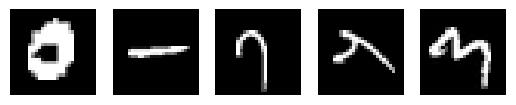

In [20]:
# Plot first 5 images
for i in range(5):
    # Reshape to 28x28
    image = normalized_data[i].reshape(28, 28)
    
    # Create subplot
    plt.subplot(1, 5, i+1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')

plt.show()


c. To prepare the data for input to the neural network, reshape each image back into a one-dimensional array of size 784.


In [7]:
images = normalized_data.reshape((-1, 28 ** 2))
images.shape

(10000, 784)

## Clustering

a. Use sklearn.decomposition.PCA.fit_transform to perform PCA with n_components = 40. This reduces the dimension of each image to a size that is more manageable, while keeping the most important aspects of the data.

In [8]:
pca_model = PCA(n_components=40)
pca_data = pca_model.fit_transform(normalized_data)
pca_model.explained_variance_ratio_.cumsum()

array([0.14481756, 0.21295908, 0.268371  , 0.31903407, 0.36318475,
       0.40078065, 0.4292748 , 0.4541704 , 0.47683364, 0.4973495 ,
       0.51573384, 0.5337144 , 0.5499963 , 0.565382  , 0.57872844,
       0.5915343 , 0.6030091 , 0.61436385, 0.6248899 , 0.63476914,
       0.6440229 , 0.65277094, 0.66113114, 0.6690985 , 0.67689687,
       0.6845401 , 0.69193757, 0.6992407 , 0.7060765 , 0.71267474,
       0.7187748 , 0.7245972 , 0.7301597 , 0.7355372 , 0.7408281 ,
       0.74598515, 0.7508841 , 0.7556717 , 0.76032317, 0.76490104],
      dtype=float32)

b. Create at least 8 clustering models using K-Means, Hierarchical, and DBSCAN, experimenting with different hyperparameters. 

c. Calculate the silhouette score for each model and tabulate the results.

### K-Means

### DBSCAN

### Hierarchical

d. Select the best model for this use case and justify your choice in Markdown.

## t-SNE

a. Use sklearn.manifold.TSNE to perform dimensional reduction on the dataset using t-SNE with n_components = 2. Try at least 8 different runs using different choices for perplexity, n_iter, and metric.

c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\sklearn\manifold\_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\sklearn\manifold\_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


[t-SNE] Computing 10 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...
[t-SNE] Computed neighbors for 10000 samples in 8.711s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 0.618025
[t-SNE] KL divergence after 250 iterations with early exaggeration: 94.287064
[t-SNE] KL divergence after 251 iterations: 17976931348623157081452742373170435

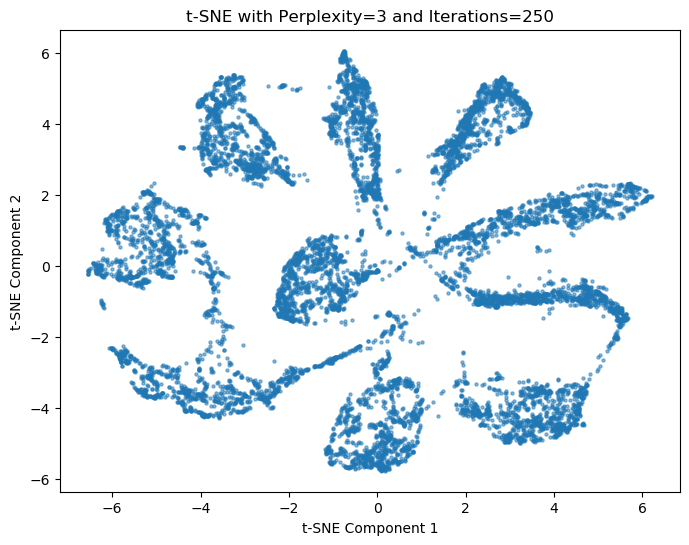

c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\sklearn\manifold\_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\sklearn\manifold\_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


[t-SNE] Computing 10 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...
[t-SNE] Computed neighbors for 10000 samples in 7.433s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 0.618025
[t-SNE] KL divergence after 250 iterations with early exaggeration: 94.644478
[t-SNE] KL divergence after 500 iterations: 2.440268


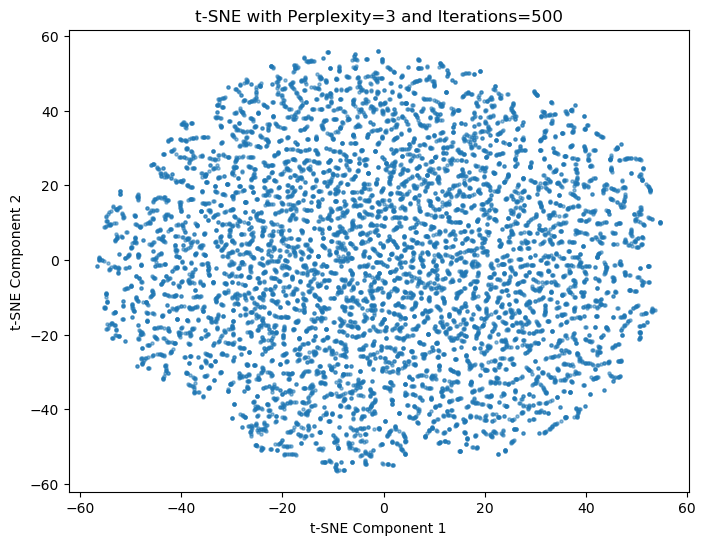

c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\sklearn\manifold\_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\sklearn\manifold\_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


[t-SNE] Computing 10 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.000s...
[t-SNE] Computed neighbors for 10000 samples in 2.185s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 0.618025
[t-SNE] KL divergence after 250 iterations with early exaggeration: 94.424515


KeyboardInterrupt: 

In [ ]:
MARKER = ['o', 'v', '1', 'p' ,'*', '+', 'x', 'd', '4', '.']
for perp in [3, 25, 50]:
    for iterations in [250, 500, 1000]:
        model_tsne = TSNE(random_state=SEED, verbose=1, n_components=2, 
                          perplexity=perp, n_iter=iterations)
        tsne_data = model_tsne.fit_transform(pca_data)
        plt.figure(figsize=(8, 6))
        plt.title(f't-SNE with Perplexity={perp} and Iterations={iterations}')
        plt.xlabel('t-SNE Component 1')
        plt.ylabel('t-SNE Component 2')
        for i in range(10):
            selections = tsne_data[mnist['labels'] == i]
            plt.scatter(selections[:,0], selections[:,1], alpha=0.2, marker=MARKER[i], s=5)
            x, y = selections.mean(axis=0)
            plt.text(x, y, str(i), fontdict={'weight': 'bold', 'size': 30})    

        plt.show()

b. Provide a scatter plot using the t-SNE components as coordinates, coloring the points according to cluster membership.

c. Print the Roman digit corresponding to each cluster at its centroid.

d. In Markdown, explain which plot provides the best visualization. You may revisit the clustering models in step 2 to improve your results.

## Conclusions

a. Display your best t-SNE plot of your best model and restate the hyperparameter choices.

b. In Markdown, discuss how well suited this dataset is for classification. Identify any digit classes that may be confused by a classification model.

c. In Markdown, explain why using PCA-reduced data is preferred over the original high-dimensional data as input for clustering and t-SNE visualization in some cases, and describe how to determine whether PCA-reduced data is appropriate to use and, if so, how to decide on the number of principal components to retain.